# Potkay Model vs Ground Truth
This notebook compares the outputs of the `PotkayModel` with the existing ground truth data.
It uses values from `param_data_template.csv` to parameterize the Potkay model, and defaults for the rest.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from garisom_tools.model.potkay import PotkayModel


## 1. Load Parameters
We load the values from `param_data_template.csv` (using the first row, e.g., POFR) and map them appropriately to the Potkay model.
Missing parameters will naturally fall back to Potkay's internal defaults.

In [6]:
# 1. Load parameter template
template_df = pd.read_csv('param_data_template.csv')
params_row = template_df.iloc[0] # Taking the first site/species for comparison

# 2. Map template parameters to Potkay constants where possible
potkay_params = {}

# Direct equivalents or standard conversions
if pd.notna(params_row.get('vmax25')):
    potkay_params['V_cmax_25'] = float(params_row['vmax25']) * 1e-6
if pd.notna(params_row.get('jmax25')):
    potkay_params['J_max_25'] = float(params_row['jmax25']) * 1e-6
if pd.notna(params_row.get('emiss')):
    potkay_params['emiss'] = float(params_row['emiss'])
if pd.notna(params_row.get('absPAR')):
    potkay_params['alpha'] = float(params_row['absPAR']) # Leaf absorptance approx
else:
    potkay_params['alpha'] = 0.5
if pd.notna(params_row.get('thetaC')):
    potkay_params['theta_c'] = float(params_row['thetaC'])
if pd.notna(params_row.get('co2AmbPPM')):
    potkay_params['c_a'] = float(params_row['co2AmbPPM']) / 1_000_000
if pd.notna(params_row.get('leafAreaIndex')):
    potkay_params['LA'] = float(params_row['leafAreaIndex']) * 0.11401  # LAI = LA / GA

potkay_params['LA'] = 0.0328

potkay_params['omega'] = 0.06132
potkay_params['theta'] = 0.000634
potkay_params['xi'] = 0.9466

print("Loaded mapped parameters from template:")
for k, v in potkay_params.items():
    print(f"  {k} = {v}")


Loaded mapped parameters from template:
  V_cmax_25 = 9.387999999999999e-05
  J_max_25 = 0.00015678
  alpha = 0.5
  theta_c = 0.98
  c_a = 0.00041935000000000003
  LA = 0.0328
  omega = 0.06132
  theta = 0.000634
  xi = 0.9466


## 2. Load Ground Data
Let's load the ground data for CCR (since it's a prominent site) and convert the meteorological headers to those required by `env_data` inside Potkay: `year`, `julian_day`, `hour`, `T_a`, `RH_a`, `R_abs`, `PPFD`.

In [7]:
# Load ground truth hourly datan
ground_df = pd.read_csv('data/ground/ccr_hourly_data.csv')

# Calculate missing physical parameters (like calculating RH from vapor pressure deficit)
# D_kPa = es(Ta) - ea
# es(Ta) roughly uses Tetens or similar: 0.611 * exp(17.27 * T / (T + 237.3))
T_a = ground_df['Tair_C']
e_s = 0.611 * np.exp((17.27 * T_a) / (T_a + 237.3))
RH_a = 1 - (ground_df['D_kPa'] / e_s)
RH_a = np.clip(RH_a, 0, 1) # bound correctly 

# Prepare environment DataFrame
env_data = pd.DataFrame({
    'year': ground_df['year'],
    'julian_day': ground_df['julian-day'],
    'hour': ground_df['standard-time'],
    'T_a': T_a,
    'RH_a': RH_a,
    'R_abs': ground_df['Solar_Wm2'] * potkay_params.get('alpha', 0.86), # approx absorbed,
    'PPFD': ground_df['Solar_Wm2'] * 4.57 * 1e-6  # Conversion from W/m2 to mol/m2/s
})

# Drop NaNs to allow a continuous run for valid data
mask = env_data.notna().all(axis=1)
env_data = env_data[mask]
ground_df = ground_df[mask]

display(env_data.head())


,year,julian_day,hour,T_a,RH_a,R_abs,PPFD
0,2023,201,0,36.498,0.246654,0.0,0.0
1,2023,201,1,34.624,0.260719,0.0,0.0
2,2023,201,2,30.874,0.298859,0.0,0.0
3,2023,201,3,30.925,0.310859,0.0,0.0
4,2023,201,4,30.293,0.338886,0.0,0.0


## 3. Run the Potkay Model
Using the assembled parameters and environment data:

In [ ]:
model_results = PotkayModel.launch_model(
    E_range=(0, 1e-2, 1e-4),
    params=potkay_params,
    env_data=env_data,
    verbose=True
)

Running Potkay model for 1560 timesteps


In [9]:
model_results.describe()

,E-MD,A_n,R_d,GW,g_c,g_tot,lambda,risk,profit,profit_idx,P_x_l,P_x_r,P_0,leaftemp,leaf-air-temp-diff,VPD,RH_l,year,julian_day,standard-time
count,1560.000000,1.560000e+03,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.0,1560.000000,1560.000000,1560.000000,1560.000000,1560.0,1560.000000,1560.000000
mean,0.919231,4.255335e-07,0.000005,52.934143,28.348529,44.549826,0.005719,0.115693,0.109974,9.192308,-0.564125,-0.298316,0.0,34.171139,0.403670,3.509345,0.896275,2023.0,233.000000,11.500000
std,1.521107,6.112122e-06,0.000002,184.250237,68.493446,104.760160,0.009564,0.002547,0.010536,15.211072,0.971908,0.482536,0.0,5.415137,0.498938,1.675837,0.190956,0.0,18.767679,6.924406
min,0.000000,-7.852888e-06,0.000002,0.000000,0.000000,0.000000,0.000016,0.109876,0.050824,0.000000,-3.188193,-1.214816,-0.0,19.104531,-0.968252,0.228629,0.223160,2023.0,201.000000,0.000000
25%,0.000000,-3.836516e-06,0.000003,0.000000,0.000000,0.000000,0.000127,0.113804,0.107739,0.000000,-0.384077,-0.383697,-0.0,30.560767,0.158374,2.329687,0.964781,2023.0,217.000000,5.750000
50%,0.000000,-2.114386e-06,0.000004,0.000000,0.000000,0.000000,0.000210,0.115557,0.113232,0.000000,-0.000000,-0.000000,-0.0,34.391769,0.175117,3.224074,1.000000,2023.0,233.000000,11.500000
75%,1.325000,0.000000e+00,0.000006,28.783921,17.807078,28.442785,0.007822,0.117332,0.116577,13.250000,0.000000,0.000000,0.0,38.153264,0.606250,4.413576,1.000000,2023.0,249.000000,17.250000
max,4.900000,1.605056e-05,0.000011,4759.435134,1102.526496,1595.467255,0.060892,0.123134,0.123072,49.000000,-0.000000,-0.000000,-0.0,47.325594,2.562639,9.836210,1.000000,2023.0,265.000000,23.000000


## 4. Evaluate and Visualize vs Ground Truth
Using fields plotted frequently: `leaftemp` / `T_l` and `GW` / Stomatal Conductance.

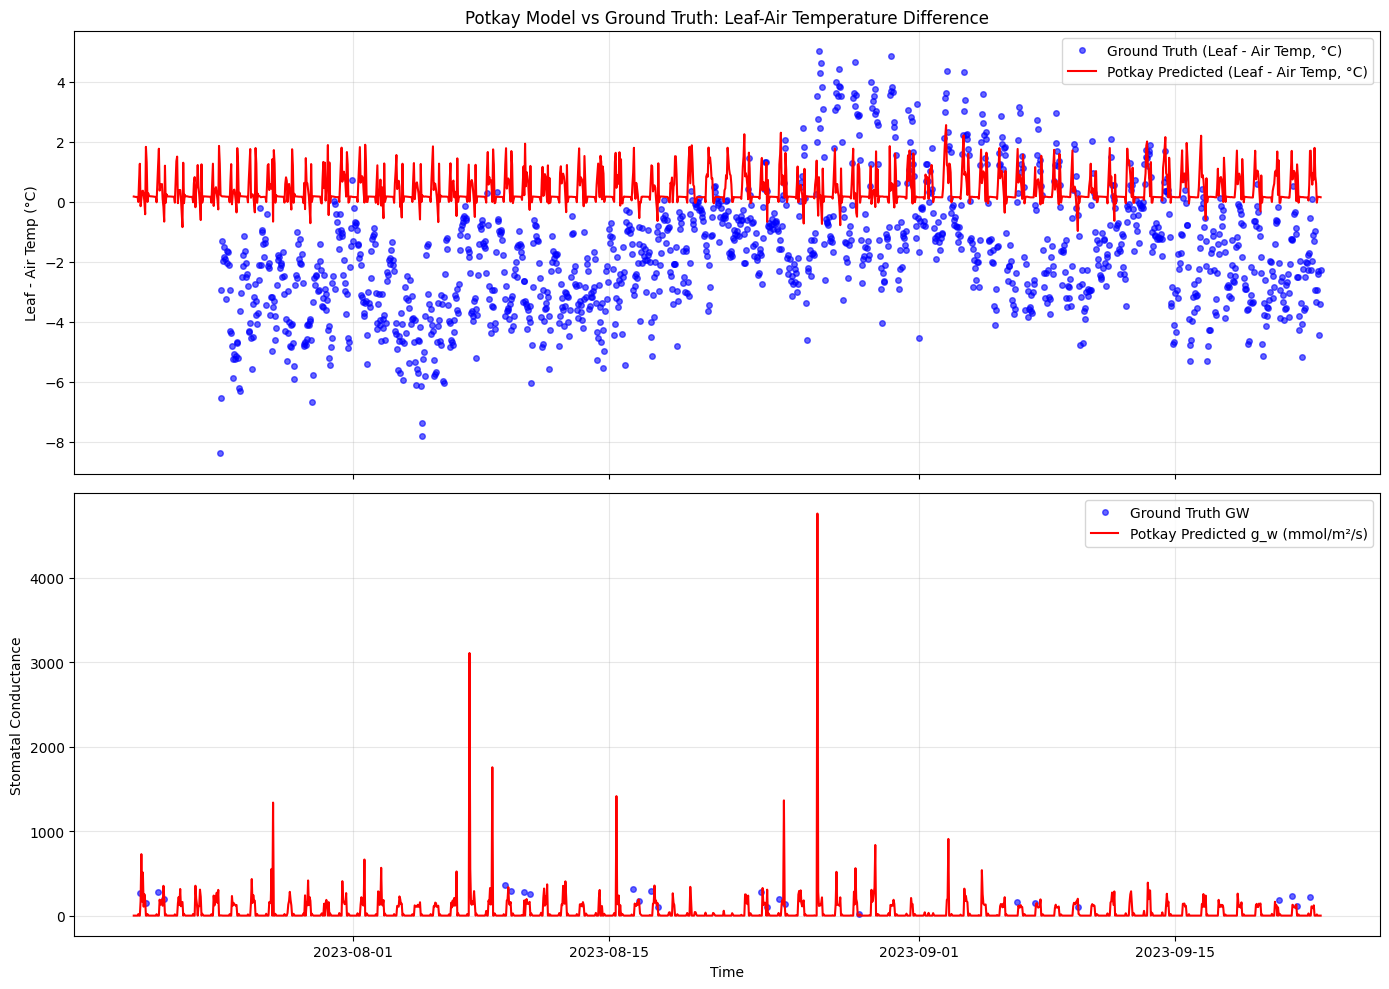

In [ ]:
# Align model results and ground data
model_results['datetime'] = pd.to_datetime(
    model_results['year'].astype(int).astype(str) + model_results['julian_day'].astype(int).astype(str), format='%Y%j'
) + pd.to_timedelta(model_results['standard-time'], unit='h')

ground_df['datetime'] = pd.to_datetime(
    ground_df['year'].astype(str) + ground_df['julian-day'].astype(str), format='%Y%j'
) + pd.to_timedelta(ground_df['standard-time'], unit='h')

# Plotting 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Subplot 1: Leaf Temp - Air Temp
ax1.plot(
    ground_df['datetime'],
    ground_df['leaf-air-temp-diff'],
    'bo',
    label='Ground Truth (Leaf - Air Temp, °C)',
    markersize=4,
    alpha=0.6
)

ax1.plot(
    model_results['datetime'],
    model_results['leaf-air-temp-diff'],
    'r-',
    label='Potkay Predicted (Leaf - Air Temp, °C)',
    linewidth=1.5
)

ax1.set_ylabel('Leaf - Air Temp (°C)')
ax1.set_title('Potkay Model vs Ground Truth: Leaf-Air Temperature Difference')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2: Stomatal Conductance (GW vs g_w)
ax2.plot(ground_df['datetime'], ground_df['GW'], 'bo', label='Ground Truth GW', markersize=4, alpha=0.6)
ax2.plot(model_results['datetime'], model_results['GW'], 'r-', label='Potkay Predicted g_w (mmol/m²/s)', linewidth=1.5)
ax2.set_xlabel('Time')
ax2.set_ylabel('Stomatal Conductance')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
